# Prabal Ghosh
## OMICS PROJECT

#

# ON  SOME RANDOM DATASET FROM T3

## using builtin model from python

In [1]:
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point
import mofax
import matplotlib.pyplot as plt



In [2]:
datadir = "C:/Users/praba/Documents/GitHub/UCA-M2-SEMESTER2/omics/MEFISTO/13233860"
data = pd.read_csv(f"{datadir}/gene_sample.csv", sep=",", index_col=0)
data

,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,Gene_10,Gene_11,...,Gene_995,Gene_996,Gene_997,Gene_998,Gene_999,Gene_1000,group,time,view,sample
Gene_1,,,,,,,,,,,,,,,,,,,,,
-0.002430,0.770287,1.539194,-0.268573,-0.595705,0.689651,-1.980843,-1.278961,1.222139,-0.053799,-0.712353,...,-2.110290,-0.768964,-0.764824,-0.409113,-1.894955,0.663783,Group1,0.000000,Expression,Group1_Sample_1
-0.914753,0.891855,-0.992654,-0.243997,0.522388,1.554266,-1.092058,-0.911009,1.776799,0.410499,-0.184165,...,-1.684041,-0.120163,0.217516,-0.828713,-2.004047,0.641395,Group1,0.010101,Expression,Group1_Sample_2
-0.914762,-0.218392,0.714618,-0.709097,0.505124,0.871507,-1.258794,-0.724633,1.059882,-0.313065,-0.466676,...,-2.373904,-0.327907,-0.025051,-0.576952,-1.793250,-0.093917,Group1,0.020202,Expression,Group1_Sample_3
-1.437530,0.450182,0.559338,-1.509047,0.275476,1.143036,-0.865766,-1.053191,1.717510,-0.566020,-1.457603,...,-2.281203,-0.945741,-0.976907,-0.604897,-0.160841,-0.120119,Group1,0.030303,Expression,Group1_Sample_4
-1.043454,-0.580924,-0.267349,-0.955929,0.006159,0.255881,-1.443561,-0.889406,1.400257,-0.314301,-0.266859,...,-1.796331,0.539780,0.656982,-1.618957,-1.545181,-0.207028,Group1,0.040404,Expression,Group1_Sample_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.172088,-1.157790,-1.451938,1.943224,1.501404,-3.485621,-1.139112,-1.408602,0.037874,-0.971069,0.210962,...,-0.937408,2.038015,0.391774,0.530516,-0.820411,-0.729341,Group2,0.959596,Expression,Group2_Sample_96
-0.867801,-1.518266,-1.223329,1.592551,1.227900,-1.811884,-1.631999,-0.095258,-0.472068,-0.195430,-0.556027,...,-0.132237,1.755551,1.444109,1.262918,0.406020,-0.793913,Group2,0.969697,Expression,Group2_Sample_97
-0.965520,-0.776358,-2.872409,2.289544,2.450995,-2.392764,-1.812428,-1.221107,-0.949336,-1.575395,0.617981,...,-1.350264,1.410991,1.202119,0.842615,0.207602,-0.210831,Group2,0.979798,Expression,Group2_Sample_98


In [ ]:

# Columns: group, view, sample, feature, value, time
data_long = df.reset_index(drop=True).melt(
    id_vars=['group', 'view', 'sample', 'time'], 
    var_name='feature', 
    value_name='value'
)


In [9]:
data_long

,group,view,sample,time,feature,value
0,Group1,Expression,Group1_Sample_1,0.000000,Gene_1,-0.002430
1,Group1,Expression,Group1_Sample_2,0.010101,Gene_1,-0.914753
2,Group1,Expression,Group1_Sample_3,0.020202,Gene_1,-0.914762
3,Group1,Expression,Group1_Sample_4,0.030303,Gene_1,-1.437530
4,Group1,Expression,Group1_Sample_5,0.040404,Gene_1,-1.043454
...,...,...,...,...,...,...
199995,Group2,Expression,Group2_Sample_96,0.959596,Gene_1000,-0.729341
199996,Group2,Expression,Group2_Sample_97,0.969697,Gene_1000,-0.793913
199997,Group2,Expression,Group2_Sample_98,0.979798,Gene_1000,-0.210831
199998,Group2,Expression,Group2_Sample_99,0.989899,Gene_1000,-0.015323


In [ ]:
# Initialize the entry point for MEFISTO
ent = entry_point()

# Set data options and load the dataset into MEFISTO
ent.set_data_options()
ent.set_data_df(data_long)

#  learn 3 latent factors
ent.set_model_options(factors=3)
ent.set_train_options()



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        


Loaded group='Group1' view='Expression' with N=100 samples and D=1000 features...
Loaded group='Group2' view='Expression' with N=100 samples and D=1000 features...



Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on

In [ ]:
groups_names = ent.data_opts['groups_names']
samples_names = ent.data_opts['samples_names']
times = []
for g in groups_names:
    # Filter sample names that belong to the current group
    group_samples = [s for s in samples if g in s]
    # Retrieve the time covariate values from the data (each sample has a unique time value)
    time_vals = df.loc[group_samples, 'time'].values.reshape(-1, 1)
    times.append(time_vals)

ent.set_covariates(times, covariates_names="time")

# Enable smooth modeling options.
ent.set_smooth_options(warping=False, model_groups=True)

# Build and run the MEFISTO model
ent.build()
ent.run()

# Save the trained model to a file
ent.save("tcga_toy_mefisto_model_1.hdf5")

Loaded 1 covariate(s) for each sample...




######################################
## Training the model with seed 534388 ##
######################################


ELBO before training: -660426.53 

Iteration 1: time=0.88, ELBO=-175227.50, deltaELBO=485199.030 (73.46752565%), Factors=3
Iteration 2: time=1.44, ELBO=-165736.50, deltaELBO=9490.998 (1.43710129%), Factors=3
Iteration 3: time=0.85, ELBO=-165353.75, deltaELBO=382.749 (0.05795480%), Factors=3
Iteration 4: time=0.93, ELBO=-165246.49, deltaELBO=107.260 (0.01624106%), Factors=3
Iteration 5: time=1.64, ELBO=-165225.20, deltaELBO=21.296 (0.00322451%), Factors=3
Iteration 6: time=0.86, ELBO=-165218.74, deltaELBO=6.453 (0.00097713%), Factors=3
Iteration 7: time=1.38, ELBO=-165214.56, deltaELBO=4.183 (0.00063334%), Factors=3
Iteration 8: time=1.24, ELBO=-165210.74, deltaELBO=3.820 (0.00057842%), Factors=3
Iteration 9: time=1.07, ELBO=-165206.99, deltaELBO=3.752 (0.00056809%), Factors=3
Optimising sigma node...
Iteration 10: time=11

In [ ]:

m = mofax.mofa_model("tcga_toy_mefisto_model_1.hdf5")

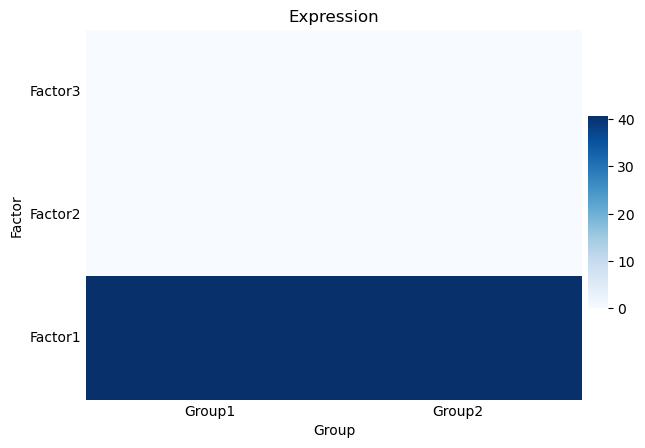

In [24]:
# Plot variance explained (R^2) by each factor using a blue color map
mofax.plot_r2(m, cmap="Blues")


In [60]:
# print(f"Samples: {m.shape[0]}")
# print(f"Features: {m.shape[1]}")
# print(f"Groups: {', '.join(m.groups)}")
# print(f"Views: {', '.join(m.views)}")
# print(f"Number of Factors: {m.nfactors}")



# # Plot a scatter plot of the latent factors versus the time covariate.
# mofax.plot_factors_scatter(m, x="time", y=range(m.nfactors), ncols=3, size=70)
# plt.show()




 - The variance explained plot (R^2) shows how much of the gene expression variability is captured by each factor.
 - The scatter plot of latent factors vs. time should show a smooth trend:
 - These latent factors can help you understand biological processes, such as tumor progression,

<Axes: title={'center': 'time_transformed'}, xlabel='Factor1', ylabel='Factor2'>

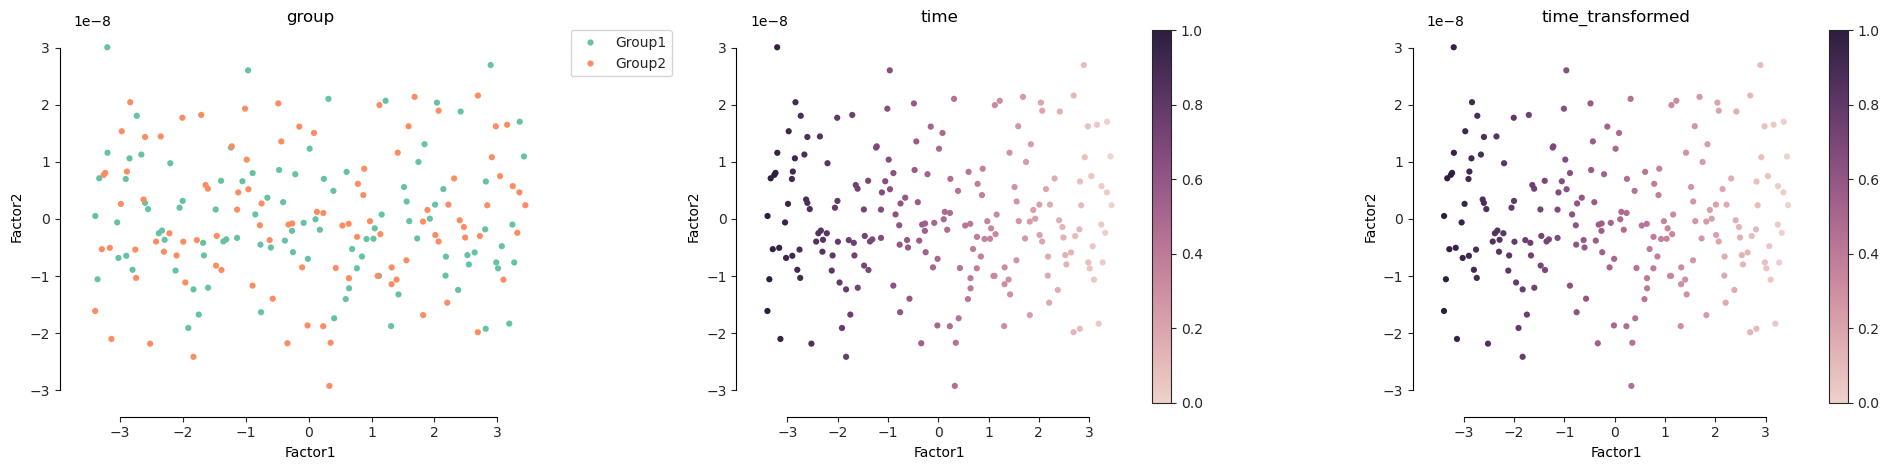

In [26]:
# Visualize factor space
mofax.plot_factors_scatter(m, x=0, y=1, color=["group", "time", "time_transformed"])



<Axes: title={'center': 'Factor3'}, xlabel='time_transformed', ylabel='Factor3'>

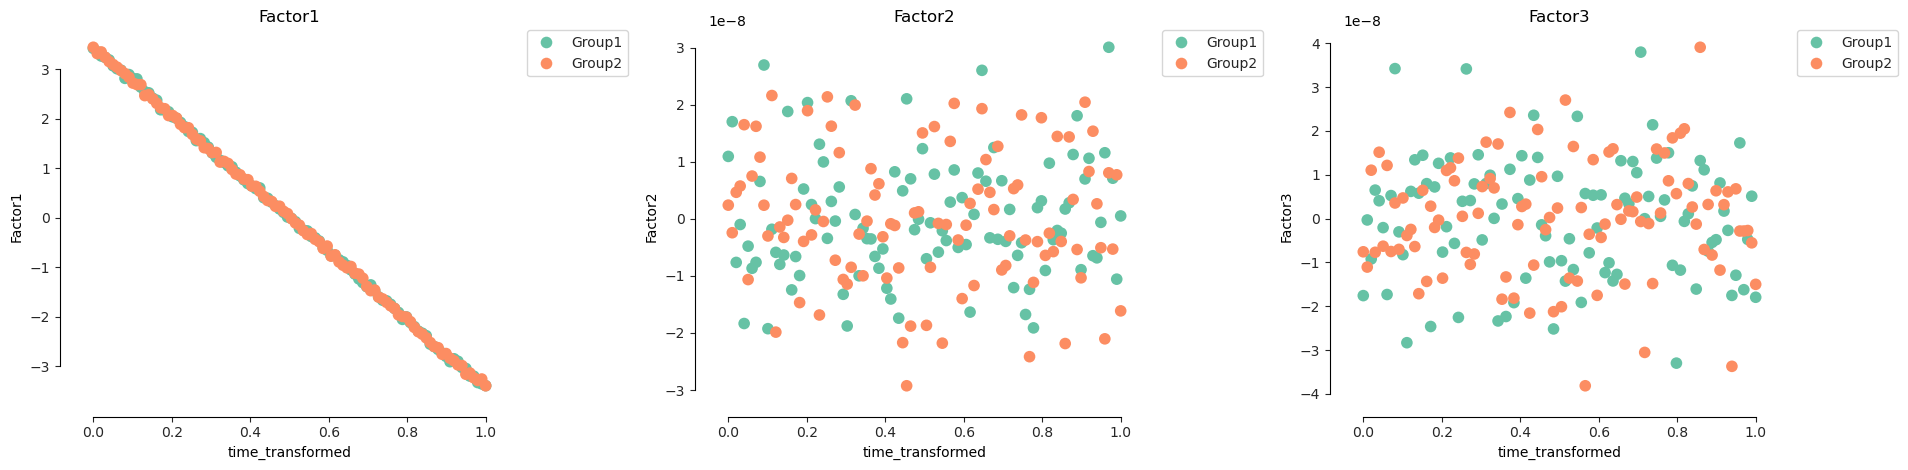

In [59]:
# Plot latent factors over developmental time
mofax.plot_factors_scatter(m, x="time_transformed", y=range(m.nfactors), ncols=3, size=70)



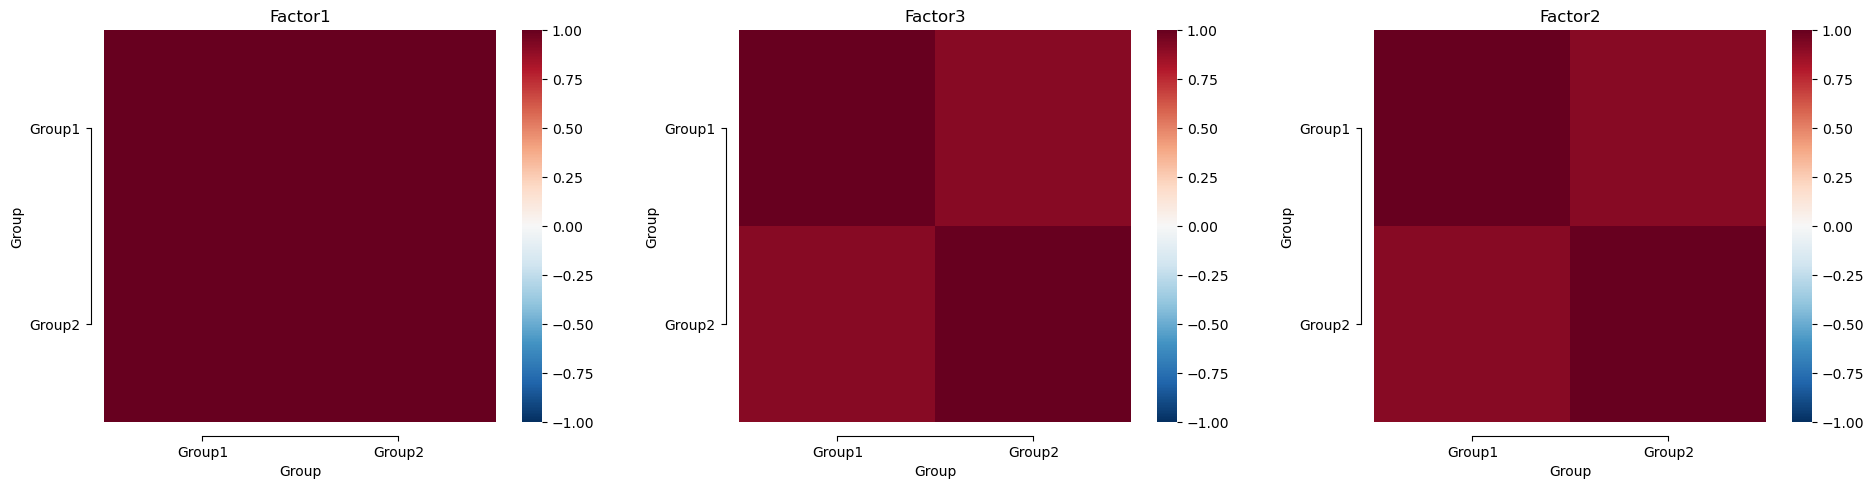

In [28]:
# Plot sharedness across species
to_plot = ["Factor1", "Factor2", "Factor3"]
mofax.plot_group_kernel(m, factors=to_plot)

plt.show()

<Axes: xlabel='Smoothness', ylabel='Factor'>

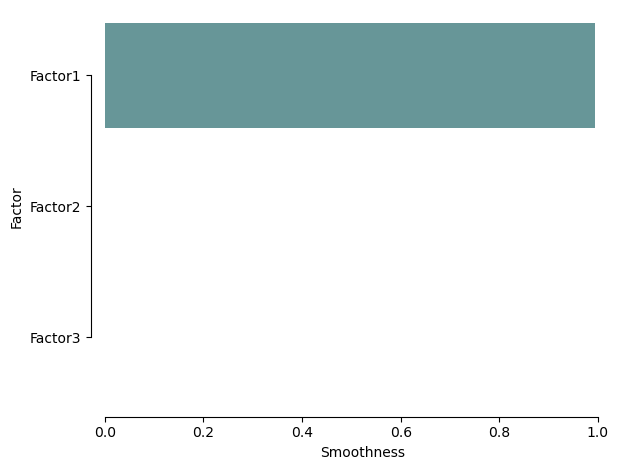

In [61]:
# Plot smoothness of factors
mofax.plot_smoothness(m)



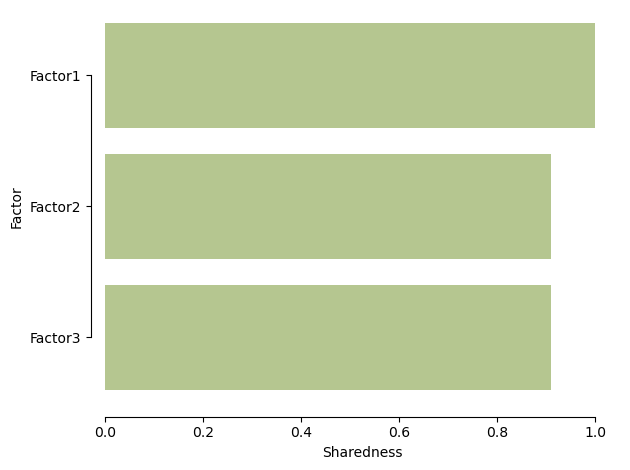

In [62]:
mofax.plot_sharedness(m);


## build the model from scratch using python

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [22]:
datadir = "C:/Users/praba/Documents/GitHub/UCA-M2-SEMESTER2/omics/MEFISTO/13233860"
df = pd.read_csv(f"{datadir}/gene_sample.csv", sep=",", index_col=0)
df

,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,Gene_10,Gene_11,...,Gene_995,Gene_996,Gene_997,Gene_998,Gene_999,Gene_1000,group,time,view,sample
Gene_1,,,,,,,,,,,,,,,,,,,,,
-0.002430,0.770287,1.539194,-0.268573,-0.595705,0.689651,-1.980843,-1.278961,1.222139,-0.053799,-0.712353,...,-2.110290,-0.768964,-0.764824,-0.409113,-1.894955,0.663783,Group1,0.000000,Expression,Group1_Sample_1
-0.914753,0.891855,-0.992654,-0.243997,0.522388,1.554266,-1.092058,-0.911009,1.776799,0.410499,-0.184165,...,-1.684041,-0.120163,0.217516,-0.828713,-2.004047,0.641395,Group1,0.010101,Expression,Group1_Sample_2
-0.914762,-0.218392,0.714618,-0.709097,0.505124,0.871507,-1.258794,-0.724633,1.059882,-0.313065,-0.466676,...,-2.373904,-0.327907,-0.025051,-0.576952,-1.793250,-0.093917,Group1,0.020202,Expression,Group1_Sample_3
-1.437530,0.450182,0.559338,-1.509047,0.275476,1.143036,-0.865766,-1.053191,1.717510,-0.566020,-1.457603,...,-2.281203,-0.945741,-0.976907,-0.604897,-0.160841,-0.120119,Group1,0.030303,Expression,Group1_Sample_4
-1.043454,-0.580924,-0.267349,-0.955929,0.006159,0.255881,-1.443561,-0.889406,1.400257,-0.314301,-0.266859,...,-1.796331,0.539780,0.656982,-1.618957,-1.545181,-0.207028,Group1,0.040404,Expression,Group1_Sample_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.172088,-1.157790,-1.451938,1.943224,1.501404,-3.485621,-1.139112,-1.408602,0.037874,-0.971069,0.210962,...,-0.937408,2.038015,0.391774,0.530516,-0.820411,-0.729341,Group2,0.959596,Expression,Group2_Sample_96
-0.867801,-1.518266,-1.223329,1.592551,1.227900,-1.811884,-1.631999,-0.095258,-0.472068,-0.195430,-0.556027,...,-0.132237,1.755551,1.444109,1.262918,0.406020,-0.793913,Group2,0.969697,Expression,Group2_Sample_97
-0.965520,-0.776358,-2.872409,2.289544,2.450995,-2.392764,-1.812428,-1.221107,-0.949336,-1.575395,0.617981,...,-1.350264,1.410991,1.202119,0.842615,0.207602,-0.210831,Group2,0.979798,Expression,Group2_Sample_98


In [23]:
print("\nData types:")
print(df.dtypes)

time_column = 1  
sample_ids = df.iloc[:, 0].values
t = df.iloc[:, time_column].values.reshape(-1, 1)

feature_df = df.iloc[:, time_column+1:]
# Replace non-numeric values with NaN and then fill NaNs with 0 (or another strategy)
for col in feature_df.columns:
    feature_df[col] = pd.to_numeric(feature_df[col], errors='coerce')
feature_df = feature_df.fillna(0)  
Y = feature_df.values

print("\nChecking for remaining non-numeric values in Y:", np.isnan(Y).any())

t_tensor = torch.tensor(t, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

n_samples, n_genes = Y.shape
print(f"Number of samples: {n_samples}, Number of genes: {n_genes}")


Data types:
Gene_2       float64
Gene_3       float64
Gene_4       float64
Gene_5       float64
Gene_6       float64
              ...   
Gene_1000    float64
group         object
time         float64
view          object
sample        object
Length: 1003, dtype: object

Checking for remaining non-numeric values in Y: False
Number of samples: 200, Number of genes: 1001


In [24]:
Y_tensor

tensor([[-0.2686, -0.5957,  0.6897,  ...,  0.0000,  0.0000,  0.0000],
        [-0.2440,  0.5224,  1.5543,  ...,  0.0101,  0.0000,  0.0000],
        [-0.7091,  0.5051,  0.8715,  ...,  0.0202,  0.0000,  0.0000],
        ...,
        [ 2.2895,  2.4510, -2.3928,  ...,  0.9798,  0.0000,  0.0000],
        [ 1.4694,  1.3489, -2.2251,  ...,  0.9899,  0.0000,  0.0000],
        [ 1.6185,  1.6458, -2.4232,  ...,  1.0000,  0.0000,  0.0000]])

In [32]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt


# # Extract time covariate and features
# time_column = df.columns.get_loc("time")  # Get the index of the 'time' column
# t = df.iloc[:, time_column].values.reshape(-1, 1)  # Time column
# feature_df = df.drop(columns=["group", "time", "view", "sample"])  # Drop non-numeric columns
# Y = feature_df.values

# # Convert to PyTorch tensors
# t_tensor = torch.tensor(t, dtype=torch.float32)
# Y_tensor = torch.tensor(Y, dtype=torch.float32)

# n_samples, n_genes = Y.shape
# print(f"Number of samples: {n_samples}, Number of genes: {n_genes}")

In [35]:


np.random.seed(42)
torch.manual_seed(42)


n_samples = 100   
n_genes = 50      
K = 3             
t = np.sort(np.random.uniform(0, 10, n_samples))
t = t.reshape(-1, 1)  

z1_true = np.sin(t).flatten()
z2_true = np.cos(t).flatten()
z3_true = (t**2).flatten()  
Z_true = np.stack([z1_true, z2_true, z3_true], axis=1)  

W_true = np.random.randn(n_genes, K)

Y_true = Z_true @ W_true.T
noise_level = 0.1
Y = Y_true + noise_level * np.random.randn(*Y_true.shape)

t_tensor = torch.tensor(t, dtype=torch.float32)  
Y_tensor = torch.tensor(Y, dtype=torch.float32)  

In [36]:
# K = 2

simple MEFISTO model from scratch

In [37]:
Z = nn.Parameter(torch.randn(n_samples, K, requires_grad=True))
W = nn.Parameter(torch.randn(n_genes, K, requires_grad=True))

# Hyperparameters for GP prior on each latent factor
sigma_f = 1.0  # signal variance
lengthscale = 1.0  # lengthscale of the squared exponential kernel
sigma_n = 1e-5  # small noise for numerical stability

def squared_exponential_kernel(t1, t2, sigma_f, lengthscale, sigma_n):
    """
    Compute the squared exponential (RBF) kernel matrix between two sets of time points.
    t1: tensor of shape (n1, 1)
    t2: tensor of shape (n2, 1)
    Returns: kernel matrix of shape (n1, n2)
    """
    diff = t1 - t2.T
    K_mat = sigma_f**2 * torch.exp(-0.5 * (diff**2) / (lengthscale**2))
    if t1.shape[0] == t2.shape[0]:
        K_mat = K_mat + sigma_n**2 * torch.eye(t1.shape[0])
    return K_mat

def gp_prior_loss(z, t, sigma_f, lengthscale, sigma_n):
    """
    Compute the negative log marginal likelihood (GP prior loss) for a latent factor vector z,
    given time points t.
    z: tensor of shape (n_samples,)
    t: tensor of shape (n_samples, 1)
    Returns a scalar loss value.
    """
    n = t.shape[0]
    K_mat = squared_exponential_kernel(t, t, sigma_f, lengthscale, sigma_n)
    L = torch.linalg.cholesky(K_mat)
    alpha = torch.cholesky_solve(z.unsqueeze(1), L)
    logdetK = 2 * torch.sum(torch.log(torch.diag(L)))
    nll = 0.5 * (z.unsqueeze(0) @ alpha) + 0.5 * logdetK + 0.5 * n * np.log(2 * np.pi)
    return nll.squeeze()

lambda_gp = 0.1

def total_loss(Y, Z, W, t, sigma_f, lengthscale, sigma_n, lambda_gp):
    # Reconstruction loss: mean squared error
    recon = torch.mean((Y - Z @ W.T)**2)
    # GP prior loss: sum over each latent factor dimension
    gp_loss = 0
    for k in range(K):
        z_k = Z[:, k]  # latent factor k, shape (n_samples,)
        gp_loss += gp_prior_loss(z_k, t, sigma_f, lengthscale, sigma_n)
    return recon + lambda_gp * gp_loss, recon, gp_loss


In [ ]:
def squared_exponential_kernel(t1, t2, sigma_f, lengthscale, sigma_n, jitter=1e-6):
    """
    Compute the squared exponential (RBF) kernel matrix between two sets of time points.
    t1: tensor of shape (n1, 1)
    t2: tensor of shape (n2, 1)
    Returns: kernel matrix of shape (n1, n2)
    """
    # Use broadcasting to compute (t1 - t2.T)^2
    diff = t1 - t2.T
    K_mat = sigma_f**2 * torch.exp(-0.5 * (diff**2) / (lengthscale**2))
    if t1.shape[0] == t2.shape[0]:
        K_mat = K_mat + (sigma_n**2 + jitter) * torch.eye(t1.shape[0])

    return K_mat

In [40]:

optimizer = optim.Adam([Z, W], lr=0.01)
n_epochs = 1000

loss_history = []
recon_history = []
gp_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss, recon_loss, gp_loss = total_loss(Y_tensor, Z, W, t_tensor, sigma_f, lengthscale, sigma_n, lambda_gp)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    recon_history.append(recon_loss.item())
    gp_history.append(gp_loss.item())
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}: Total Loss = {loss.item():.4f}, Recon Loss = {recon_loss.item():.4f}, GP Loss = {gp_loss.item():.4f}")


Epoch 200/1000: Total Loss = 288682.9062, Recon Loss = 1151.5835, GP Loss = 2875313.0000
Epoch 400/1000: Total Loss = 13544.5000, Recon Loss = 1137.3784, GP Loss = 124071.2188
Epoch 600/1000: Total Loss = 5361.5366, Recon Loss = 1128.6486, GP Loss = 42328.8789
Epoch 800/1000: Total Loss = 3032.2310, Recon Loss = 1122.3683, GP Loss = 19098.6250
Epoch 1000/1000: Total Loss = 2152.4512, Recon Loss = 1116.7747, GP Loss = 10356.7637


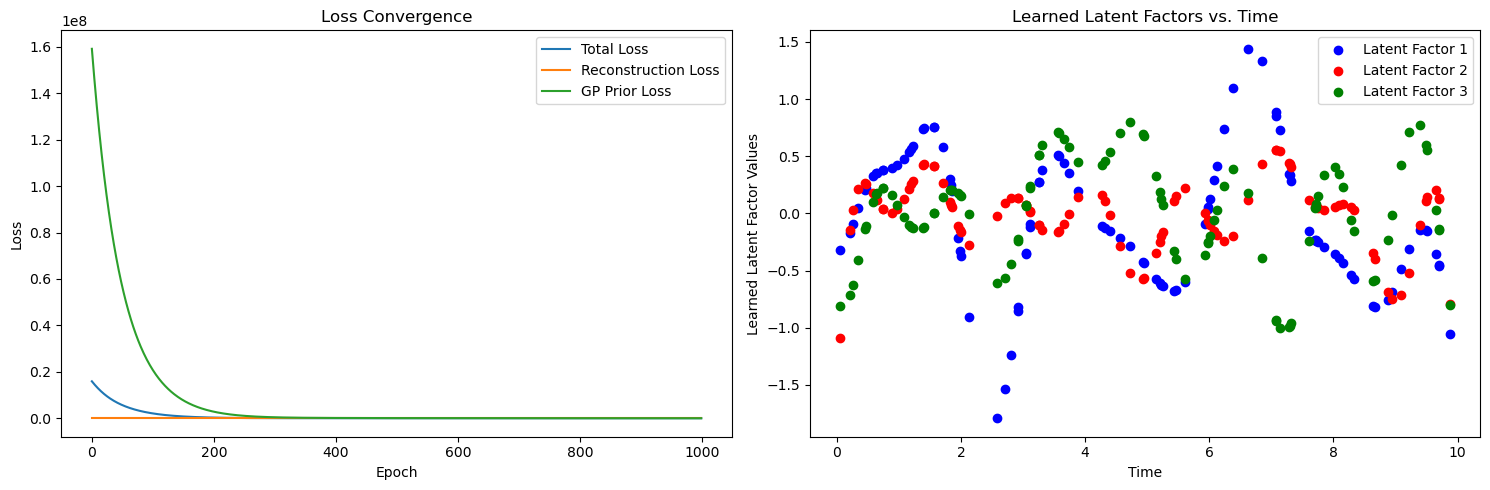

In [41]:
Z_learned = Z.detach().cpu().numpy()

plt.figure(figsize=(15, 5))

# Plot loss convergence
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Total Loss')
plt.plot(recon_history, label='Reconstruction Loss')
plt.plot(gp_history, label='GP Prior Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Convergence')

# Plot all three latent factors
plt.subplot(1, 2, 2)
plt.scatter(t, Z_learned[:, 0], color='blue', label='Latent Factor 1')
plt.scatter(t, Z_learned[:, 1], color='red', label='Latent Factor 2')
plt.scatter(t, Z_learned[:, 2], color='green', label='Latent Factor 3')
plt.xlabel('Time')
plt.ylabel('Learned Latent Factor Values')
plt.legend()
plt.title('Learned Latent Factors vs. Time')

plt.tight_layout()
plt.show()

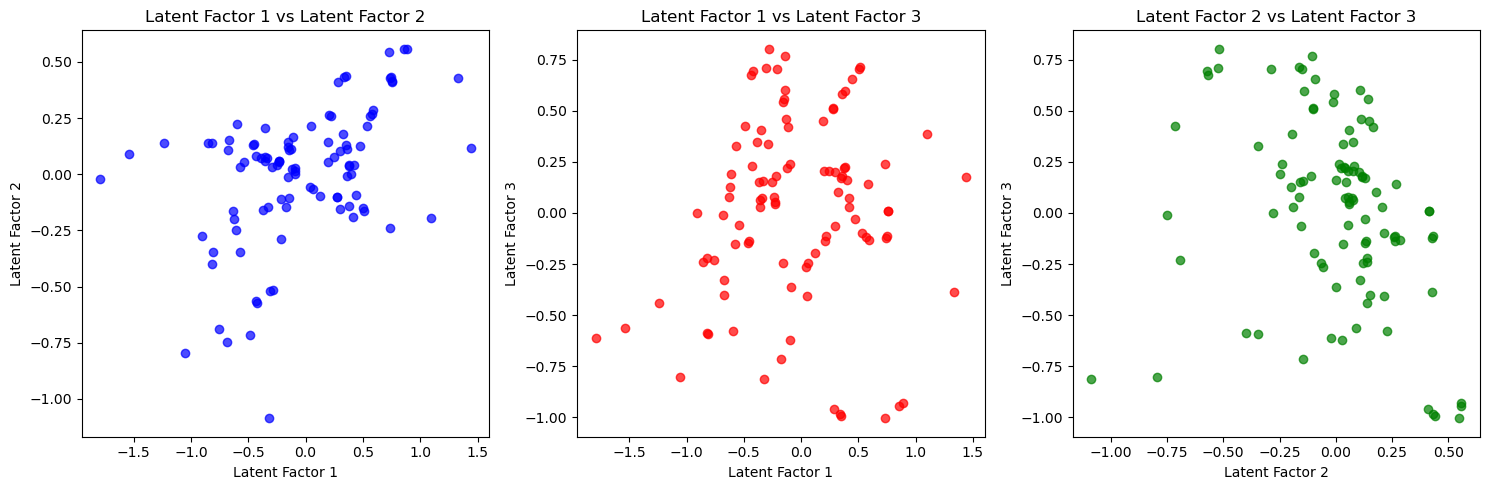

In [42]:
Z_learned = Z.detach().cpu().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(Z_learned[:, 0], Z_learned[:, 1], color='blue', alpha=0.7)
plt.xlabel('Latent Factor 1')
plt.ylabel('Latent Factor 2')
plt.title('Latent Factor 1 vs Latent Factor 2')

plt.subplot(1, 3, 2)
plt.scatter(Z_learned[:, 0], Z_learned[:, 2], color='red', alpha=0.7)
plt.xlabel('Latent Factor 1')
plt.ylabel('Latent Factor 3')
plt.title('Latent Factor 1 vs Latent Factor 3')

plt.subplot(1, 3, 3)
plt.scatter(Z_learned[:, 1], Z_learned[:, 2], color='green', alpha=0.7)
plt.xlabel('Latent Factor 2')
plt.ylabel('Latent Factor 3')
plt.title('Latent Factor 2 vs Latent Factor 3')

plt.tight_layout()
plt.show()

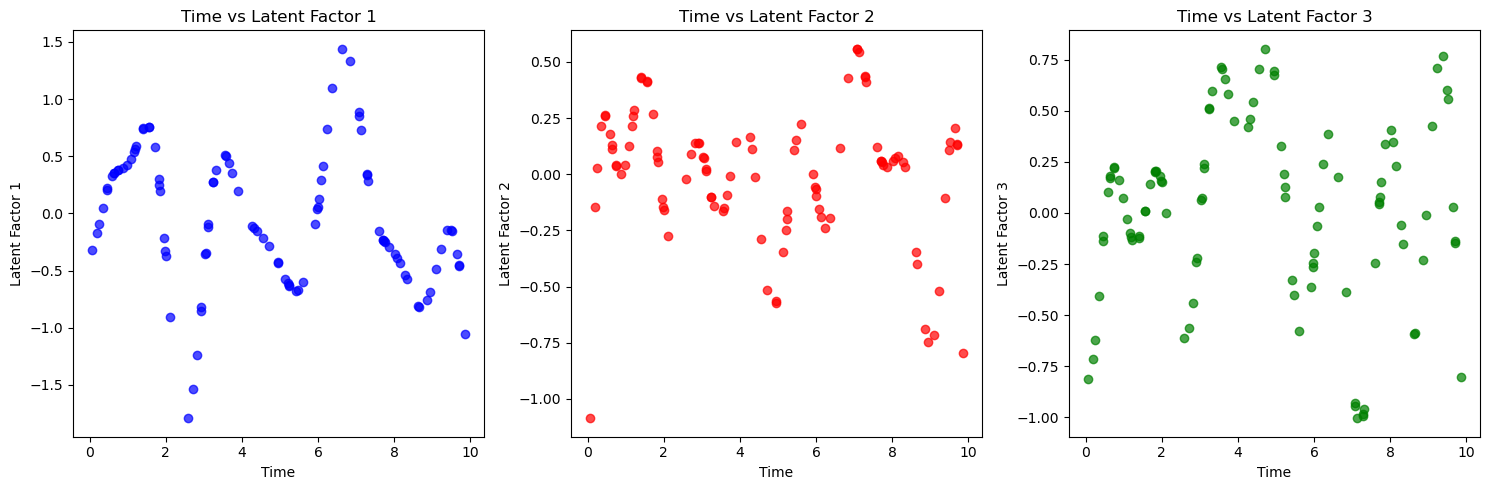

In [43]:
Z_learned = Z.detach().cpu().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(t, Z_learned[:, 0], color='blue', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Latent Factor 1')
plt.title('Time vs Latent Factor 1')

plt.subplot(1, 3, 2)
plt.scatter(t, Z_learned[:, 1], color='red', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Latent Factor 2')
plt.title('Time vs Latent Factor 2')

plt.subplot(1, 3, 3)
plt.scatter(t, Z_learned[:, 2], color='green', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Latent Factor 3')
plt.title('Time vs Latent Factor 3')

plt.tight_layout()
plt.show()

In [44]:
# Z_learned = Z.detach().cpu().numpy()

# n_factors = Z_learned.shape[1]

# groups = np.random.choice(["Group 1", "Group 2"], size=t.shape[0])
# group_colors = {"Group 1": "blue", "Group 2": "red" }
# colors = [group_colors[group] for group in groups]

# ncols = 3  
# nrows = (n_factors + ncols - 1) // ncols  
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

# axes = axes.flatten()

# # Plot each latent factor against time
# for i in range(n_factors):
#     for group in group_colors.keys():
#         group_mask = np.array(groups) == group
#         axes[i].scatter(
#             t[group_mask], Z_learned[group_mask, i], 
#             s=70, alpha=0.7, label=group, color=group_colors[group]
#         )
#     axes[i].set_xlabel("Time")
#     axes[i].set_ylabel(f"Latent Factor {i + 1}")
#     axes[i].set_title(f"Time vs Latent Factor {i + 1}")
#     axes[i].legend()

# for j in range(n_factors, len(axes)):
#     axes[j].axis("off")

# plt.tight_layout()
# plt.show()

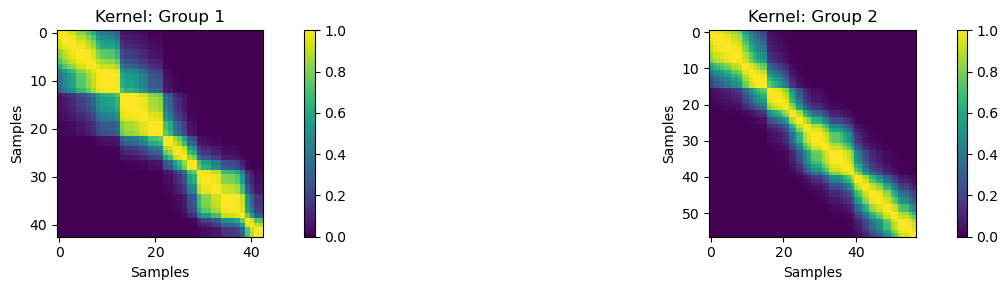

In [45]:
groups = np.random.choice(["Group 1", "Group 2"], size=t.shape[0])

unique_groups = np.unique(groups)

# Compute kernel matrices for each group
group_kernels = {}
for group in unique_groups:
    group_mask = np.array(groups) == group
    t_group = t_tensor[group_mask]
    kernel_matrix = squared_exponential_kernel(t_group, t_group, sigma_f=1.0, lengthscale=1.0, sigma_n=1e-5)
    group_kernels[group] = kernel_matrix.detach().cpu().numpy()

ncols = 2  
nrows = (len(unique_groups) + ncols - 1) // ncols  
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows))

axes = axes.flatten()

for i, group in enumerate(unique_groups):
    ax = axes[i]
    kernel_matrix = group_kernels[group]
    im = ax.imshow(kernel_matrix, cmap="viridis")
    ax.set_title(f"Kernel: {group}")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Samples")
    fig.colorbar(im, ax=ax)

for j in range(len(unique_groups), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()